# 🧠 Head Gesture Recognition System — ML Pipeline

**IISc Edge AI Course Project | April 2026**

### Hardware
| Component | Detail |
|---|---|
| Sensor boards | 2 × Arduino Nicla Vision (LSM6DSOX IMU) |
| Placement | Master → right temple, Slave → left temple |
| Sampling rate | 50 Hz |
| Communication | UDP over Wi-Fi |

### Classes
| Index | Gesture |
|---|---|
| 1 | Nod |
| 2 | Head Shake |
| 3 | Tilt Left |
| 4 | Tilt Right |
| 5 | Look Up |
| 6 | Look Down |
| 7 | Idle |

### Pipeline Overview
1. Data Loading & Cleaning  
2. Exploratory Data Analysis  
3. Sliding-Window Segmentation  
4. Dual-IMU Feature Engineering  
5. Normalisation & Train/Test Split  
6. Baseline Models (Decision Tree, Random Forest)  
7. Keras TinyML Model  
8. Evaluation & Confusion Matrix  
9. TFLite Export  


---
## 0. Imports & Configuration

In [3]:
import os
import re
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.signal import butter, filtfilt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, learning_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)
from sklearn.manifold import TSNE
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import joblib

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow : {tf.__version__}')
print(f'NumPy      : {np.__version__}')
print(f'Pandas     : {pd.__version__}')

# ── Paths ─────────────────────────────────────────────────────────────────
DATA_DIR   = r'dataset/imu_data'
OUTPUT_DIR = r'model_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Windowing Configuration ────────────────────────────────────────────────
SAMPLE_RATE = 50          # Hz
WINDOW_SEC  = 1.0         # seconds per window
OVERLAP_FRAC = 0.5        # 50% overlap
WINDOW_SIZE  = int(SAMPLE_RATE * WINDOW_SEC)   # 50 samples
STEP_SIZE    = int(WINDOW_SIZE * (1 - OVERLAP_FRAC))  # 25 samples

# ── Gesture Classes ────────────────────────────────────────────────────────
CLASS_NAMES = {
    1: 'Nod',
    2: 'Head_Shake',
    3: 'Tilt_Left',
    4: 'Tilt_Right',
    5: 'Look_Up',
    6: 'Look_Down',
    7: 'Idle'
}
NUM_CLASSES = len(CLASS_NAMES)

print(f'\nWindow     : {WINDOW_SIZE} samples ({WINDOW_SEC}s @ {SAMPLE_RATE}Hz)')
print(f'Step       : {STEP_SIZE} samples ({OVERLAP_FRAC*100:.0f}% overlap)')
print(f'Classes    : {NUM_CLASSES} gestures')

TensorFlow : 2.21.0
NumPy      : 2.4.0
Pandas     : 2.3.3

Window     : 50 samples (1.0s @ 50Hz)
Step       : 25 samples (50% overlap)
Classes    : 7 gestures


---
## 1. Data Loading & Cleaning

In [4]:
# Column names from the CSV schema
COL_NAMES = ['timestamp',
             'ax1','ay1','az1','gx1','gy1','gz1',   # Master IMU
             'ax2','ay2','az2','gx2','gy2','gz2',   # Slave IMU
             'activity']

IMU_AXES_M = ['ax1','ay1','az1','gx1','gy1','gz1']  # master
IMU_AXES_S = ['ax2','ay2','az2','gx2','gy2','gz2']  # slave
ALL_IMU    = IMU_AXES_M + IMU_AXES_S


def load_dataframes(data_dir: str) -> pd.DataFrame:
    """Load all non-test CSV files and concatenate into one DataFrame."""
    csv_files = glob.glob(os.path.join(data_dir, '*.csv'))
    frames = []
    skipped = []
    for f in csv_files:
        fname = os.path.basename(f).lower()
        # Skip calibration / test files
        if fname.startswith('test'):
            skipped.append(fname)
            continue
        try:
            df = pd.read_csv(f, header=0, names=COL_NAMES)
            frames.append(df)
        except Exception as e:
            print(f'  [WARN] Could not read {fname}: {e}')
    print(f'Loaded  : {len(frames)} files')
    print(f'Skipped : {len(skipped)} test/calibration files → {skipped}')
    return pd.concat(frames, ignore_index=True)


raw = load_dataframes(DATA_DIR)
print(f'\nRaw shape : {raw.shape}')
raw.head(3)

Loaded  : 28 files
Skipped : 0 test/calibration files → []

Raw shape : (141751, 14)


,timestamp,ax1,ay1,az1,gx1,gy1,gz1,ax2,ay2,az2,gx2,gy2,gz2,activity
0,36380,0.170776,-0.902222,-0.342407,-5.126952,-10.864256,23.25439,0.148682,0.978150,0.005249,0.244141,-0.915527,-21.240230,1_Nod_Abha
1,36420,0.143799,-0.906128,-0.347290,-6.164550,-14.282224,28.38134,0.124390,0.982666,0.003540,0.854492,0.000000,-24.169920,1_Nod_Abha
2,36460,0.115723,-0.907593,-0.352661,-7.690428,-16.418460,31.73828,0.107056,0.988037,0.000000,1.708984,0.732422,-27.221676,1_Nod_Abha


In [5]:
# ── Cleaning ────────────────────────────────────────────────────────────────

# 1. Drop the header row that was included as data (some files have it)
raw = raw[raw['timestamp'] != 'timestamp'].copy()

# 2. Convert all IMU columns to float
for col in ALL_IMU + ['timestamp']:
    raw[col] = pd.to_numeric(raw[col], errors='coerce')

# 3. Standardise the activity label: extract ONLY the class index prefix
#    e.g.  '1_Nod_Abha'  ->  1 ,  '2_Head_Shake__Abha'  ->  2
def extract_class_idx(label: str) -> int:
    m = re.match(r'^(\d+)', str(label).strip())
    return int(m.group(1)) if m else -1

raw['class_idx'] = raw['activity'].apply(extract_class_idx)
raw = raw[raw['class_idx'].between(1, 7)].copy()   # keep only valid classes

# 4. Drop rows with NaNs in IMU columns (e.g. sensor glitches)
before = len(raw)
raw.dropna(subset=ALL_IMU, inplace=True)
after  = len(raw)
print(f'Dropped {before - after} rows with NaN values (out of {before})')

# 5. Outlier clip: gyroscope occasionally has an extreme spike (seen in data)
#    Clip at ±500 deg/s  (well beyond any human head motion)
GYRO_CLIP = 500.0
ACCEL_CLIP = 16.0   # ±16g
for col in ['ax1','ay1','az1','ax2','ay2','az2']:
    raw[col] = raw[col].clip(-ACCEL_CLIP, ACCEL_CLIP)
for col in ['gx1','gy1','gz1','gx2','gy2','gz2']:
    raw[col] = raw[col].clip(-GYRO_CLIP, GYRO_CLIP)

print(f'\nClean shape : {raw.shape}')
print('\nClass distribution:')
dist = raw.groupby('class_idx')['activity'].count().reset_index()
dist.columns = ['class_idx', 'samples']
dist['gesture'] = dist['class_idx'].map(CLASS_NAMES)
print(dist.to_string(index=False))

Dropped 0 rows with NaN values (out of 141751)

Clean shape : (141751, 15)

Class distribution:
 class_idx  samples    gesture
         1    16205        Nod
         2    19229 Head_Shake
         3    21190  Tilt_Left
         4    20257 Tilt_Right
         5    20333    Look_Up
         6    22107  Look_Down
         7    22430       Idle


---
## 2. Exploratory Data Analysis

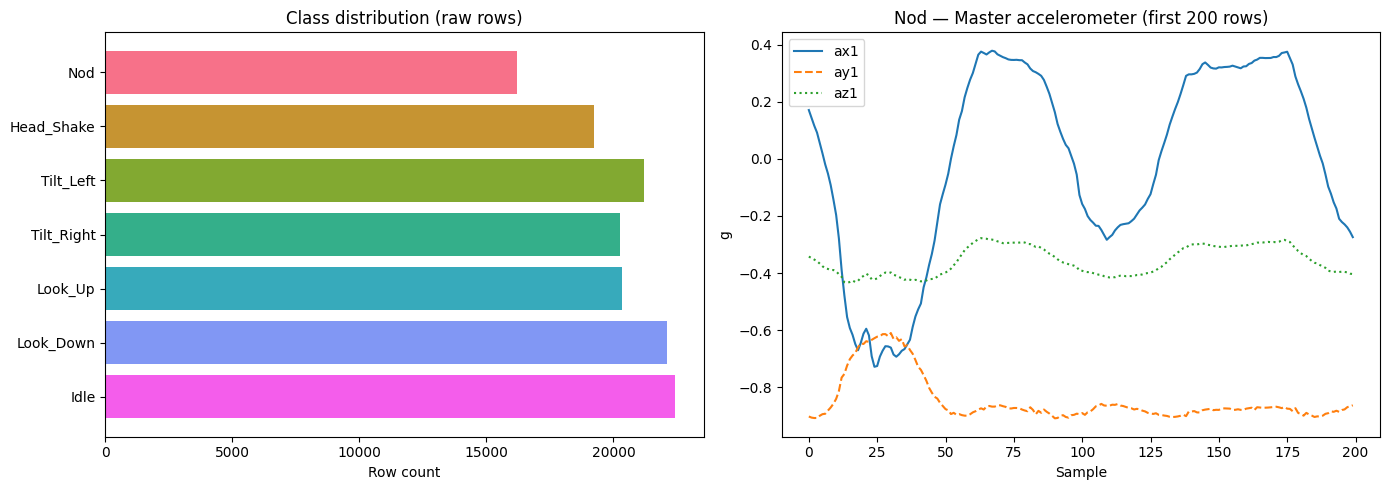

Saved → eda_overview.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class balance
counts = raw['class_idx'].value_counts().sort_index()
labels = [CLASS_NAMES[c] for c in counts.index]
axes[0].barh(labels, counts.values, color=sns.color_palette('husl', NUM_CLASSES))
axes[0].set_xlabel('Row count')
axes[0].set_title('Class distribution (raw rows)')
axes[0].invert_yaxis()

# Sample gesture trace — Nod, Master IMU accelerometer
nod_sample = raw[raw['class_idx'] == 1].head(200)
for col, ls in zip(['ax1','ay1','az1'], ['-','--',':']):
    axes[1].plot(nod_sample[col].values, ls, label=col)
axes[1].set_title('Nod — Master accelerometer (first 200 rows)')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('g')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_overview.png', dpi=150)
plt.show()
print('Saved → eda_overview.png')

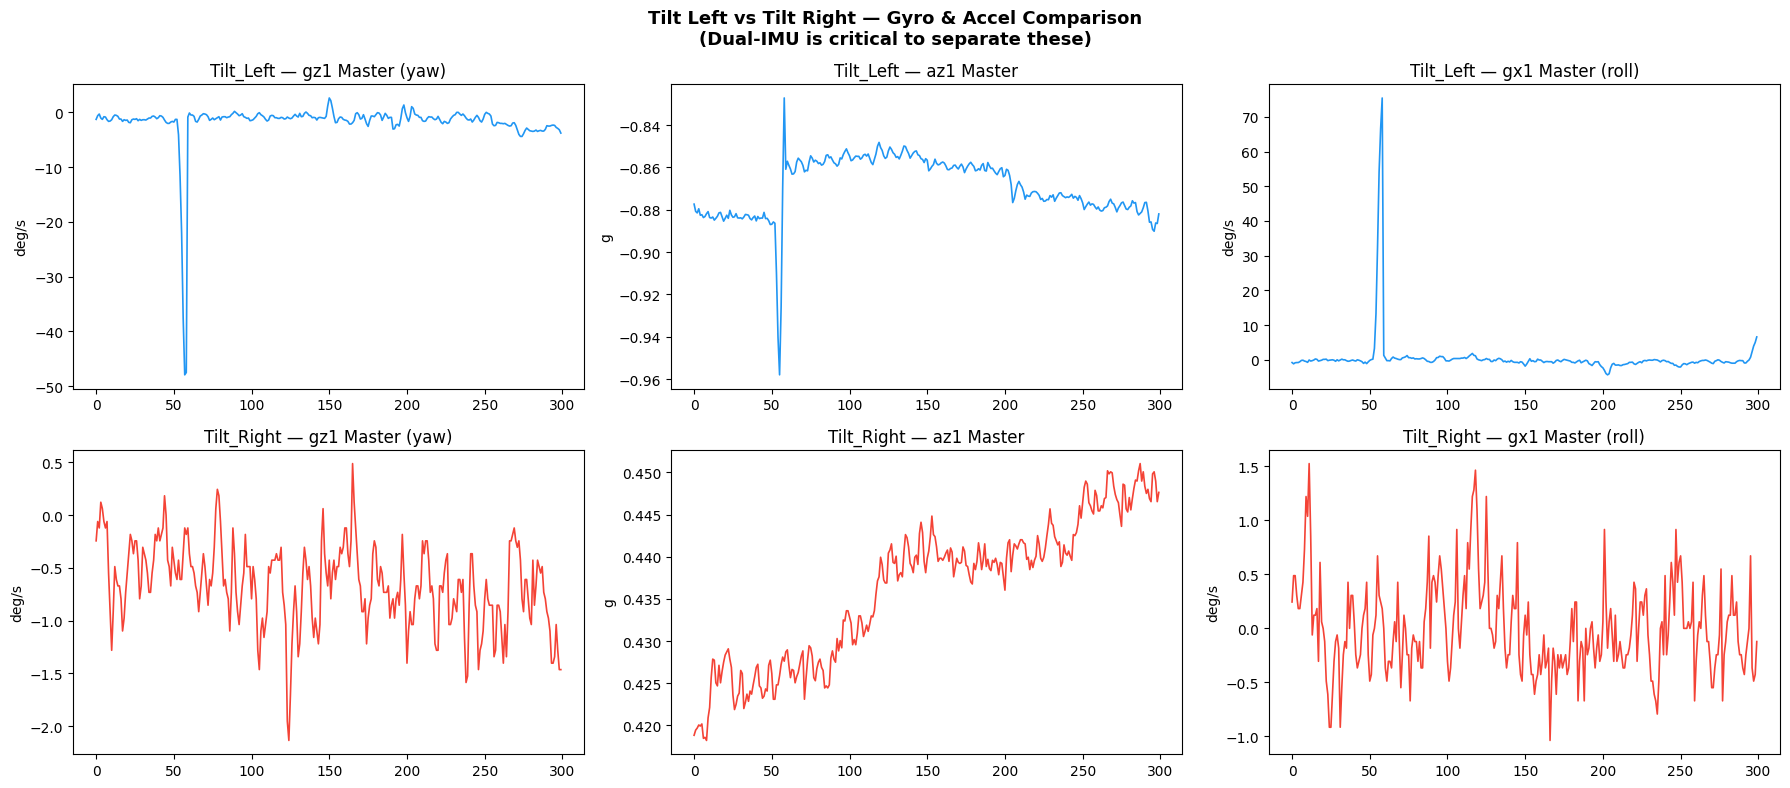

In [7]:
# Compare Tilt Left vs Tilt Right gyroscope (the hardest discrimination)
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
colors = {'Tilt_Left': '#2196F3', 'Tilt_Right': '#F44336'}

for i, cls_idx in enumerate([3, 4]):
    subset = raw[raw['class_idx'] == cls_idx].head(300)
    label  = CLASS_NAMES[cls_idx]
    for j, (col, title) in enumerate(zip(
            ['gz1', 'az1', 'gx1'],
            ['gz1 Master (yaw)', 'az1 Master', 'gx1 Master (roll)'])):
        axes[i, j].plot(subset[col].values, color=list(colors.values())[i], lw=1.2)
        axes[i, j].set_title(f'{label} — {title}')
        axes[i, j].set_ylabel('deg/s' if 'g' in col else 'g')

plt.suptitle('Tilt Left vs Tilt Right — Gyro & Accel Comparison\n'
             '(Dual-IMU is critical to separate these)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/tilt_comparison.png', dpi=150)
plt.show()

---
## 3. Sliding-Window Segmentation

In [8]:
def sliding_window_segments(df: pd.DataFrame,
                            window_size: int = WINDOW_SIZE,
                            step_size: int = STEP_SIZE) -> list:
    """
    Split each contiguous per-class block into overlapping windows.
    Returns a list of (window_df, class_idx) tuples.
    """
    segments = []
    # Sort by class then timestamp so windows are contiguous within a gesture file
    df_sorted = df.sort_values(['class_idx', 'timestamp']).reset_index(drop=True)

    for cls_idx in df_sorted['class_idx'].unique():
        cls_data = df_sorted[df_sorted['class_idx'] == cls_idx][ALL_IMU].values
        n = len(cls_data)
        start = 0
        while start + window_size <= n:
            window = cls_data[start: start + window_size]   # shape (50, 12)
            segments.append((window, cls_idx))
            start += step_size

    return segments


segments = sliding_window_segments(raw)
print(f'Total windows : {len(segments)}')

# Window class distribution
win_classes = pd.Series([s[1] for s in segments])
print('\nWindows per class:')
for c, n in win_classes.value_counts().sort_index().items():
    print(f'  [{c}] {CLASS_NAMES[c]:12s} → {n} windows')

Total windows : 5661

Windows per class:
  [1] Nod          → 647 windows
  [2] Head_Shake   → 768 windows
  [3] Tilt_Left    → 846 windows
  [4] Tilt_Right   → 809 windows
  [5] Look_Up      → 812 windows
  [6] Look_Down    → 883 windows
  [7] Idle         → 896 windows


---
## 4. Dual-IMU Feature Engineering

For each 1-second window we compute **11 statistical features** for each of the **12 IMU channels** (6 master + 6 slave) = **132 base features**.  
We also compute **4 cross-IMU correlation features** specifically designed to discriminate Tilt Left vs Tilt Right.

In [9]:
def extract_features_from_window(window: np.ndarray) -> dict:
    """
    window : (WINDOW_SIZE, 12) array
              columns = ax1,ay1,az1,gx1,gy1,gz1, ax2,ay2,az2,gx2,gy2,gz2
    Returns a flat feature dict.
    """
    features = {}

    col_names = ALL_IMU   # 12 channel names

    # ── Per-channel statistical features (11 per channel × 12 = 132) ────────
    for i, col in enumerate(col_names):
        x = window[:, i].astype(np.float64)
        features[f'{col}_mean']  = np.mean(x)
        features[f'{col}_std']   = np.std(x)
        features[f'{col}_min']   = np.min(x)
        features[f'{col}_max']   = np.max(x)
        features[f'{col}_var']   = np.var(x)
        features[f'{col}_rms']   = np.sqrt(np.mean(x**2))
        features[f'{col}_eng']   = np.sum(x**2)
        features[f'{col}_iqr']   = stats.iqr(x)
        features[f'{col}_med']   = np.median(x)
        features[f'{col}_skew']  = stats.skew(x)
        features[f'{col}_kurt']  = stats.kurtosis(x)

    # ── Spectral features: dominant frequency & spectral entropy ─────────────
    #    Computed for the 3 gyroscope channels on each IMU (6 channels)
    for col_idx, col in enumerate(['gx1','gy1','gz1','gx2','gy2','gz2']):
        x = window[:, col_names.index(col)].astype(np.float64)
        freqs = np.fft.rfftfreq(len(x), d=1.0/SAMPLE_RATE)
        fft_mag = np.abs(np.fft.rfft(x))
        # Dominant frequency
        features[f'{col}_domfreq'] = freqs[np.argmax(fft_mag)]
        # Spectral entropy
        psd = fft_mag**2
        psd_norm = psd / (psd.sum() + 1e-10)
        features[f'{col}_spec_ent'] = -np.sum(psd_norm * np.log(psd_norm + 1e-10))

    # ── Cross-IMU symmetry features (dual-IMU advantage) ─────────────────────
    #    These features capture the DIFFERENCE between the two IMU signals,
    #    which is the key discriminator for Tilt Left vs Tilt Right.

    # Gyroscope x-axis (roll): difference between master and slave
    gx1 = window[:, col_names.index('gx1')]
    gx2 = window[:, col_names.index('gx2')]
    gz1 = window[:, col_names.index('gz1')]
    gz2 = window[:, col_names.index('gz2')]
    ay1 = window[:, col_names.index('ay1')]
    ay2 = window[:, col_names.index('ay2')]

    # Mean difference in roll gyro  (±ve indicates which side tilts more)
    features['cross_gx_mean_diff']  = np.mean(gx1) - np.mean(gx2)
    # RMS difference
    features['cross_gx_rms_diff']   = np.sqrt(np.mean(gx1**2)) - np.sqrt(np.mean(gx2**2))
    # Mean difference in yaw gyro (gz)
    features['cross_gz_mean_diff']  = np.mean(gz1) - np.mean(gz2)
    # Pearson correlation between gz1 and gz2 (in-phase vs anti-phase)
    if np.std(gz1) > 1e-6 and np.std(gz2) > 1e-6:
        features['cross_gz_corr'] = float(np.corrcoef(gz1, gz2)[0, 1])
    else:
        features['cross_gz_corr'] = 0.0
    # Sum of absolute gyro energy (total rotation energy)
    features['total_gyro_energy'] = np.sum(gx1**2) + np.sum(gz1**2) + np.sum(gx2**2) + np.sum(gz2**2)
    # Vertical acceleration agreement (ay1 ≈ ay2 when balanced, differs when tilting)
    features['cross_ay_mean_diff'] = np.mean(ay1) - np.mean(ay2)

    return features


# Build the feature matrix
feature_rows = []
labels_list  = []

for window, cls_idx in segments:
    feat = extract_features_from_window(window)
    feature_rows.append(feat)
    labels_list.append(cls_idx)

feat_df = pd.DataFrame(feature_rows)
y_raw   = np.array(labels_list)   # class indices 1-7

print(f'Feature matrix shape : {feat_df.shape}')
print(f'Feature names sample  : {list(feat_df.columns[:8])} ...')
print(f'NaN features          : {feat_df.isna().sum().sum()}')

# Fill any NaN from near-zero std (e.g. skew of constant window)
feat_df.fillna(0.0, inplace=True)

Feature matrix shape : (5661, 150)
Feature names sample  : ['ax1_mean', 'ax1_std', 'ax1_min', 'ax1_max', 'ax1_var', 'ax1_rms', 'ax1_eng', 'ax1_iqr'] ...
NaN features          : 4144


In [40]:
feat_df.head()

,ax1_mean,ax1_std,ax1_min,ax1_max,ax1_var,ax1_rms,ax1_eng,ax1_iqr,ax1_med,ax1_skew,...,gy2_domfreq,gy2_spec_ent,gz2_domfreq,gz2_spec_ent,cross_gx_mean_diff,cross_gx_rms_diff,cross_gz_mean_diff,cross_gz_corr,total_gyro_energy,cross_ay_mean_diff
0,-0.426162,0.277146,-0.728149,0.170776,0.076810,0.508354,12.921203,0.453339,-0.552979,0.777152,...,2.0,1.560793,1.0,1.024049,-1.680908,6.418762,13.383791,-0.980277,159937.662318,-1.567014
1,-0.137759,0.426697,-0.725464,0.378540,0.182070,0.448383,10.052387,0.965241,-0.106934,-0.070948,...,2.0,1.851403,0.0,0.632163,5.686034,5.489189,-51.711419,-0.957483,118161.637245,-1.653662
2,0.225244,0.149034,-0.126831,0.378540,0.022211,0.270085,3.647297,0.244934,0.294067,-0.808775,...,2.0,1.322484,1.0,1.530300,-0.246582,3.774147,-4.244382,-0.991562,85132.596000,-1.845120
3,-0.011860,0.231961,-0.283569,0.346680,0.053806,0.232264,2.697330,0.471619,-0.133606,0.407704,...,1.0,1.482009,0.0,0.885943,-3.200683,1.639712,22.473144,-0.961716,42550.293858,-1.843972
4,-0.013862,0.230268,-0.283569,0.337402,0.053023,0.230685,2.660777,0.475647,-0.132141,0.393562,...,1.0,1.696874,1.0,1.099391,2.014160,2.928394,-19.926757,-0.980981,45894.092959,-1.846773


---
## 5. Normalisation & Train / Test Split

In [10]:
X = feat_df.values

# Encode labels 1-7 → 0-6
le = LabelEncoder()
y  = le.fit_transform(y_raw)   # 0-indexed
print('Label encoding:', dict(zip(le.classes_, range(NUM_CLASSES))))

# 80 / 20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# StandardScaler — fit only on training data
scaler   = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Save scaler for inference
joblib.dump(scaler, f'{OUTPUT_DIR}/scaler.pkl')
np.save(f'{OUTPUT_DIR}/feature_names.npy', np.array(feat_df.columns.tolist()))

print(f'\nTrain size : {X_train_s.shape}')
print(f'Test  size : {X_test_s.shape}')
print(f'Features   : {X_train_s.shape[1]}')

Label encoding: {np.int64(1): 0, np.int64(2): 1, np.int64(3): 2, np.int64(4): 3, np.int64(5): 4, np.int64(6): 5, np.int64(7): 6}

Train size : (4528, 150)
Test  size : (1133, 150)
Features   : 150


---
## 6. Dimensionality Reduction — t-SNE

Running t-SNE …


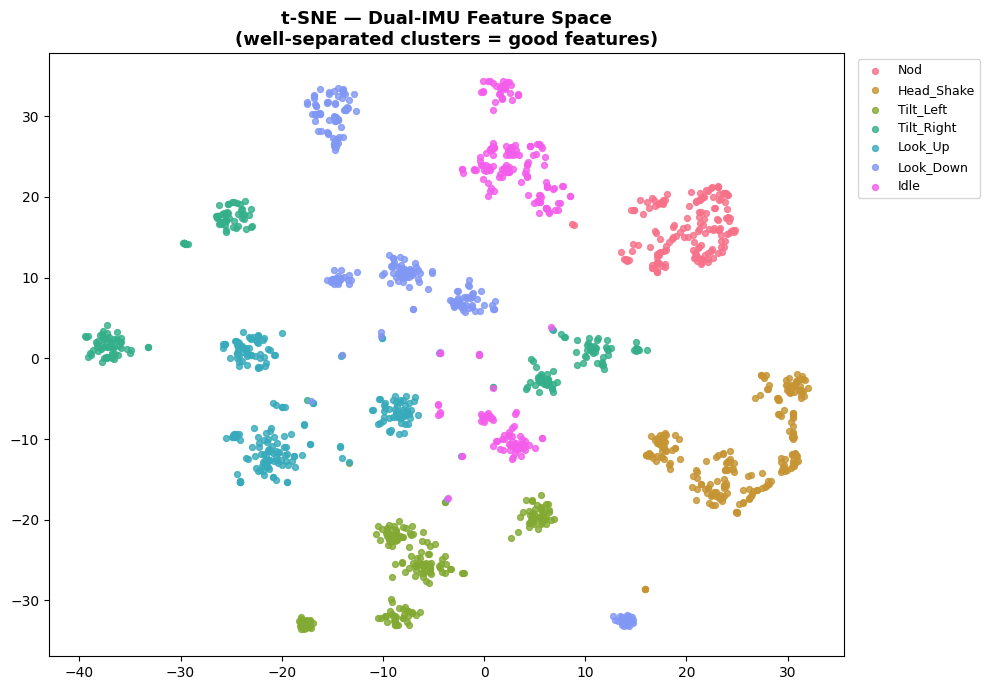

Saved → tsne_features.png


In [11]:
# Run t-SNE on up to 1500 training samples for speed
MAX_TSNE = 1500
idx = np.random.choice(len(X_train_s), min(MAX_TSNE, len(X_train_s)), replace=False)
X_tsne_in = X_train_s[idx]
y_tsne    = y_train[idx]

print('Running t-SNE …')
tsne   = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=500)
X_emb  = tsne.fit_transform(X_tsne_in)

palette = sns.color_palette('husl', NUM_CLASSES)
gesture_labels = [CLASS_NAMES[le.classes_[c]] for c in y_tsne]

plt.figure(figsize=(10, 7))
for i, gesture in enumerate(CLASS_NAMES.values()):
    mask = np.array(gesture_labels) == gesture
    plt.scatter(X_emb[mask, 0], X_emb[mask, 1],
                color=palette[i], label=gesture, s=18, alpha=0.8)
plt.title('t-SNE — Dual-IMU Feature Space\n(well-separated clusters = good features)',
          fontsize=13, fontweight='bold')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/tsne_features.png', dpi=150)
plt.show()
print('Saved → tsne_features.png')

---
## 7. Baseline Models

### 7a. Decision Tree

Decision Tree Accuracy : 100.00%

Classification Report:
              precision    recall  f1-score   support

         Nod       1.00      1.00      1.00       129
  Head_Shake       1.00      1.00      1.00       154
   Tilt_Left       1.00      1.00      1.00       169
  Tilt_Right       1.00      1.00      1.00       162
     Look_Up       1.00      1.00      1.00       163
   Look_Down       1.00      1.00      1.00       177
        Idle       1.00      1.00      1.00       179

    accuracy                           1.00      1133
   macro avg       1.00      1.00      1.00      1133
weighted avg       1.00      1.00      1.00      1133



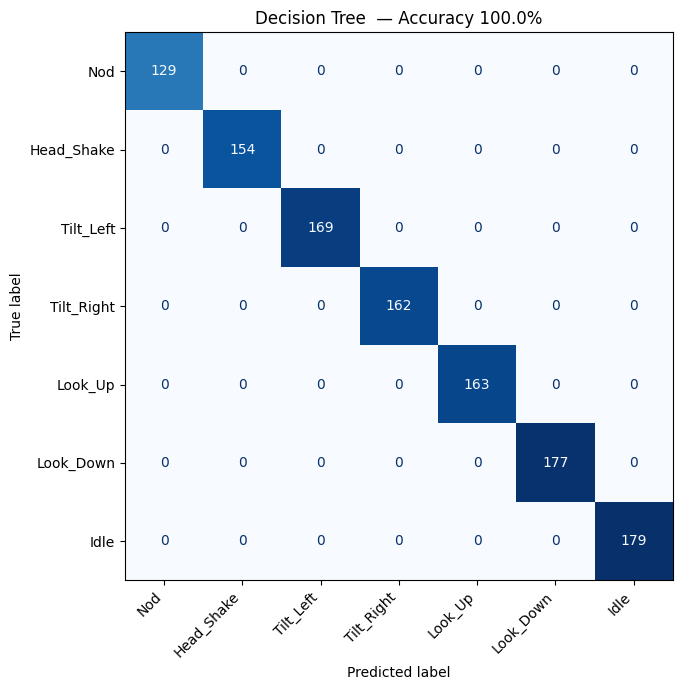

['model_output/decision_tree.pkl']

In [12]:
dt = DecisionTreeClassifier(criterion='entropy', max_depth=20, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
acc_dt    = accuracy_score(y_test, y_pred_dt)
print(f'Decision Tree Accuracy : {acc_dt*100:.2f}%')
print('\nClassification Report:')
target_names = [CLASS_NAMES[le.classes_[i]] for i in range(NUM_CLASSES)]
print(classification_report(y_test, y_pred_dt, target_names=target_names))

# Confusion matrix
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_dt),
    display_labels=target_names
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Decision Tree  — Accuracy {acc_dt*100:.1f}%')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/cm_decision_tree.png', dpi=150)
plt.show()

joblib.dump(dt, f'{OUTPUT_DIR}/decision_tree.pkl')

In [13]:
import m2cgen as m2c

# Generate Python code
code = m2c.export_to_python(dt)

# Save to file
with open("model_score.py", "w") as f:
    f.write(code)

print("m2cgen code generated!")

m2cgen code generated!


In [14]:
import m2cgen as m2c

code = m2c.export_to_python(dt)

print(code)

def score(input):
    if input[93] <= 0.24413678795099258:
        if input[148] <= 6447.829833984375:
            if input[68] <= 0.5161135196685791:
                if input[69] <= 0.07299799844622612:
                    var0 = [0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0]
                else:
                    if input[48] <= 48.387667655944824:
                        var0 = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0]
                    else:
                        var0 = [0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]
            else:
                var0 = [0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0]
        else:
            if input[116] <= 10047.057373046875:
                if input[3] <= -0.1484375186264515:
                    var0 = [0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0]
                else:
                    if input[96] <= 0.047515749000012875:
                        var0 = [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
                    else:
                        var0 = [0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0]


In [26]:
for i, col in enumerate(feat_df.columns):
    print(f"{i:3d} -> {col}")

  0 -> ax1_mean
  1 -> ax1_std
  2 -> ax1_min
  3 -> ax1_max
  4 -> ax1_var
  5 -> ax1_rms
  6 -> ax1_eng
  7 -> ax1_iqr
  8 -> ax1_med
  9 -> ax1_skew
 10 -> ax1_kurt
 11 -> ay1_mean
 12 -> ay1_std
 13 -> ay1_min
 14 -> ay1_max
 15 -> ay1_var
 16 -> ay1_rms
 17 -> ay1_eng
 18 -> ay1_iqr
 19 -> ay1_med
 20 -> ay1_skew
 21 -> ay1_kurt
 22 -> az1_mean
 23 -> az1_std
 24 -> az1_min
 25 -> az1_max
 26 -> az1_var
 27 -> az1_rms
 28 -> az1_eng
 29 -> az1_iqr
 30 -> az1_med
 31 -> az1_skew
 32 -> az1_kurt
 33 -> gx1_mean
 34 -> gx1_std
 35 -> gx1_min
 36 -> gx1_max
 37 -> gx1_var
 38 -> gx1_rms
 39 -> gx1_eng
 40 -> gx1_iqr
 41 -> gx1_med
 42 -> gx1_skew
 43 -> gx1_kurt
 44 -> gy1_mean
 45 -> gy1_std
 46 -> gy1_min
 47 -> gy1_max
 48 -> gy1_var
 49 -> gy1_rms
 50 -> gy1_eng
 51 -> gy1_iqr
 52 -> gy1_med
 53 -> gy1_skew
 54 -> gy1_kurt
 55 -> gz1_mean
 56 -> gz1_std
 57 -> gz1_min
 58 -> gz1_max
 59 -> gz1_var
 60 -> gz1_rms
 61 -> gz1_eng
 62 -> gz1_iqr
 63 -> gz1_med
 64 -> gz1_skew
 65 -> g

In [28]:
training_order = feat_df.columns.tolist()

for i, col in enumerate(training_order[:20]):
    print(i, col)

print("Total:", len(training_order))

0 ax1_mean
1 ax1_std
2 ax1_min
3 ax1_max
4 ax1_var
5 ax1_rms
6 ax1_eng
7 ax1_iqr
8 ax1_med
9 ax1_skew
10 ax1_kurt
11 ay1_mean
12 ay1_std
13 ay1_min
14 ay1_max
15 ay1_var
16 ay1_rms
17 ay1_eng
18 ay1_iqr
19 ay1_med
Total: 150


In [30]:
import json

feature_order = feat_df.columns.tolist()

with open("feature_order.json", "w") as f:
    json.dump(feature_order, f, indent=2)

print("Saved feature_order.json")

Saved feature_order.json


In [31]:
import json

with open("feature_order.json") as f:
    saved_order = json.load(f)

print("Match:", training_order == saved_order)

Match: True


In [32]:
training_order = feat_df.columns.tolist()

dummy_window = np.random.randn(WINDOW_SIZE, 12)
feat_dict = extract_features_from_window(dummy_window)

runtime_order = list(feat_dict.keys())

print("Match:", training_order == runtime_order)

Match: True


In [36]:
code = m2c.export_to_python(dt)

In [37]:
exec(code)

In [39]:
sample = X_test[0].tolist()

print("Sklearn:", dt.predict([sample])[0])
print("m2cgen :", score(sample))

Sklearn: 3
m2cgen : [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0]


### 7b. Random Forest + Feature Importance

Random Forest Accuracy : 100.00%
              precision    recall  f1-score   support

         Nod       1.00      1.00      1.00       129
  Head_Shake       1.00      1.00      1.00       154
   Tilt_Left       1.00      1.00      1.00       169
  Tilt_Right       1.00      1.00      1.00       162
     Look_Up       1.00      1.00      1.00       163
   Look_Down       1.00      1.00      1.00       177
        Idle       1.00      1.00      1.00       179

    accuracy                           1.00      1133
   macro avg       1.00      1.00      1.00      1133
weighted avg       1.00      1.00      1.00      1133



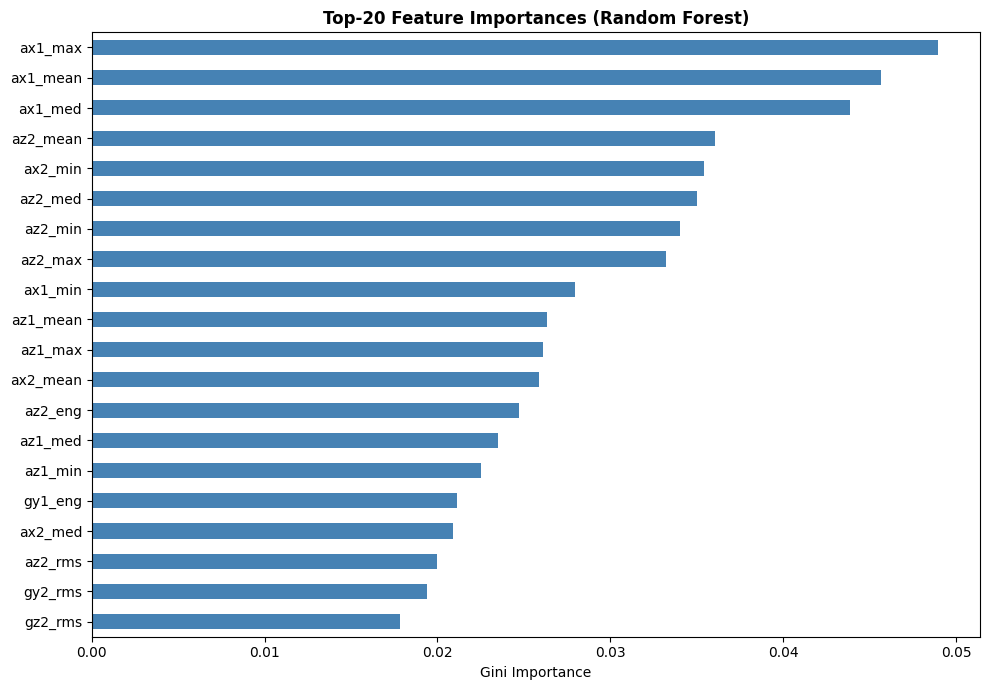


Top-10 features:
ax1_max     0.048944
ax1_mean    0.045651
ax1_med     0.043848
az2_mean    0.036074
ax2_min     0.035422
az2_med     0.035007
az2_min     0.034013
az2_max     0.033236
ax1_min     0.027983
az1_mean    0.026308


['model_output/random_forest.pkl']

In [15]:
rf = RandomForestClassifier(n_estimators=150, max_depth=20, random_state=42, n_jobs=-1)
rf.fit(X_train_s, y_train)

y_pred_rf = rf.predict(X_test_s)
acc_rf    = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest Accuracy : {acc_rf*100:.2f}%')
print(classification_report(y_test, y_pred_rf, target_names=target_names))

# Feature importance — Top 20
importances = pd.Series(rf.feature_importances_, index=feat_df.columns)
top20 = importances.nlargest(20)

plt.figure(figsize=(10, 7))
top20.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top-20 Feature Importances (Random Forest)', fontweight='bold')
plt.xlabel('Gini Importance')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/feature_importance_rf.png', dpi=150)
plt.show()

print('\nTop-10 features:')
print(importances.nlargest(10).to_string())

joblib.dump(rf, f'{OUTPUT_DIR}/random_forest.pkl')

### 7c. Learning Curve (Decision Tree)

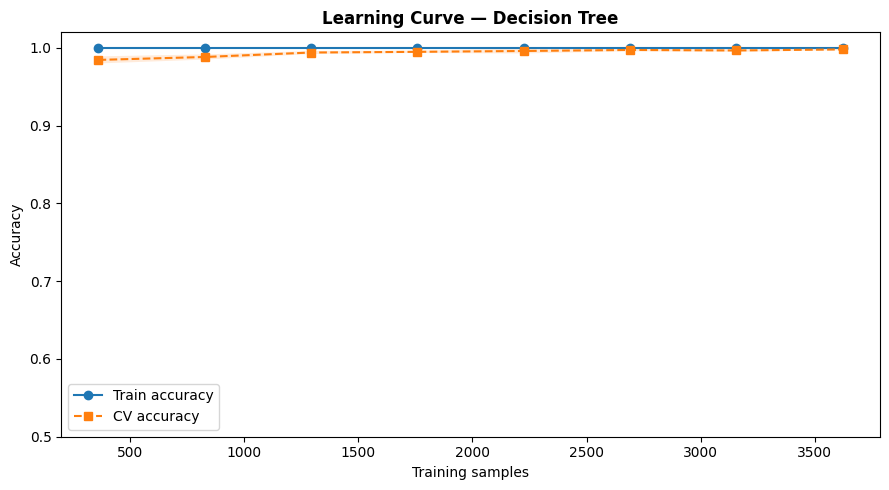

In [16]:
train_sizes, train_sc, val_sc = learning_curve(
    DecisionTreeClassifier(criterion='entropy', max_depth=20, random_state=42),
    X_train_s, y_train,
    cv=5, scoring='accuracy',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 8)
)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_sc.mean(axis=1), 'o-', label='Train accuracy')
plt.fill_between(train_sizes,
                 train_sc.mean(1) - train_sc.std(1),
                 train_sc.mean(1) + train_sc.std(1), alpha=0.15)
plt.plot(train_sizes, val_sc.mean(axis=1), 's--', label='CV accuracy')
plt.fill_between(train_sizes,
                 val_sc.mean(1) - val_sc.std(1),
                 val_sc.mean(1) + val_sc.std(1), alpha=0.15)
plt.xlabel('Training samples')
plt.ylabel('Accuracy')
plt.title('Learning Curve — Decision Tree', fontweight='bold')
plt.legend()
plt.ylim(0.5, 1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/learning_curve.png', dpi=150)
plt.show()

---
## 8. Keras TinyML Model

We build a compact Dense neural network targeting deployment on the Arduino Nicla Vision via TFLite.  
Design principles:
- Small footprint (< 50 KB quantised)
- Batch Normalisation for training stability
- Dropout for regularisation  
- Softmax output for 7-class classification

In [17]:
NUM_FEATURES = X_train_s.shape[1]

# One-hot encode labels for Keras
y_train_oh = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_oh  = tf.keras.utils.to_categorical(y_test,  NUM_CLASSES)


def build_tinyml_model(num_features: int, num_classes: int) -> keras.Model:
    """Compact feed-forward model suitable for TFLite INT8 quantisation."""
    inp = layers.Input(shape=(num_features,), name='features')

    x = layers.Dense(128, activation='relu', name='fc1')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(64, activation='relu', name='fc2')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(32, activation='relu', name='fc3')(x)
    x = layers.Dropout(0.2)(x)

    out = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = keras.Model(inputs=inp, outputs=out, name='HeadGesture_TinyMLP')
    return model


model = build_tinyml_model(NUM_FEATURES, NUM_CLASSES)
model.summary()

# Count parameters
total_params = model.count_params()
print(f'\nTotal parameters : {total_params:,}')
print(f'Estimated size (float32) : {total_params*4/1024:.1f} KB')
print(f'Estimated size (INT8)    : {total_params*1/1024:.1f} KB')

Model: "HeadGesture_TinyMLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │        19,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (Dense)                     │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,663 (119.78 KB)

 Trainable params: 30,279 (118.28 KB)

 Non-trainable params: 384 (1.50 KB)


Total parameters : 30,663
Estimated size (float32) : 119.8 KB
Estimated size (INT8)    : 29.9 KB


In [18]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=15,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=7, min_lr=1e-5, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=f'{OUTPUT_DIR}/best_model.h5',
        monitor='val_accuracy', save_best_only=True, verbose=0
    )
]

history = model.fit(
    X_train_s, y_train_oh,
    validation_split=0.15,
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
115/121 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5437 - loss: 1.3695

121/121 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7760 - loss: 0.7435 - val_accuracy: 0.9912 - val_loss: 0.0772 - learning_rate: 0.0010
Epoch 2/100
114/121 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9766 - loss: 0.1423

121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9797 - loss: 0.1159 - val_accuracy: 0.9971 - val_loss: 0.0130 - learning_rate: 0.0010
Epoch 3/100
118/121 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9853 - loss: 0.0661

121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9873 - loss: 0.0573 - val_accuracy: 0.9985 - val_loss: 0.0043 - learning_rate: 0.0010
Epoch 4/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9948 - loss: 0.0338 - val_accuracy: 0.9985 - val_loss: 0.0024 - learning_rate: 0.0010
Epoch 5/100
117/121 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9928 - loss: 0.0294

121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9948 - loss: 0.0263 - val_accuracy: 1.0000 - val_loss: 0.0012 - learning_rate: 0.0010
Epoch 6/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9961 - loss: 0.0177 - val_accuracy: 1.0000 - val_loss: 6.7196e-04 - learning_rate: 0.0010
Epoch 7/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9964 - loss: 0.0158 - val_accuracy: 1.0000 - val_loss: 5.1530e-04 - learning_rate: 0.0010
Epoch 8/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9969 - loss: 0.0157 - val_accuracy: 1.0000 - val_loss: 8.6797e-04 - learning_rate: 0.0010
Epoch 9/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9971 - loss: 0.0107 - val_accuracy: 1.0000 - val_loss: 3.3121e-04 - learning_rate: 0.0010
Epoch 10/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9987 - loss: 0.0078 - val_accuracy: 1.0000 - val_loss: 1.6163e-04 - learning_rate: 0.0010
Epoch 11/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9979 

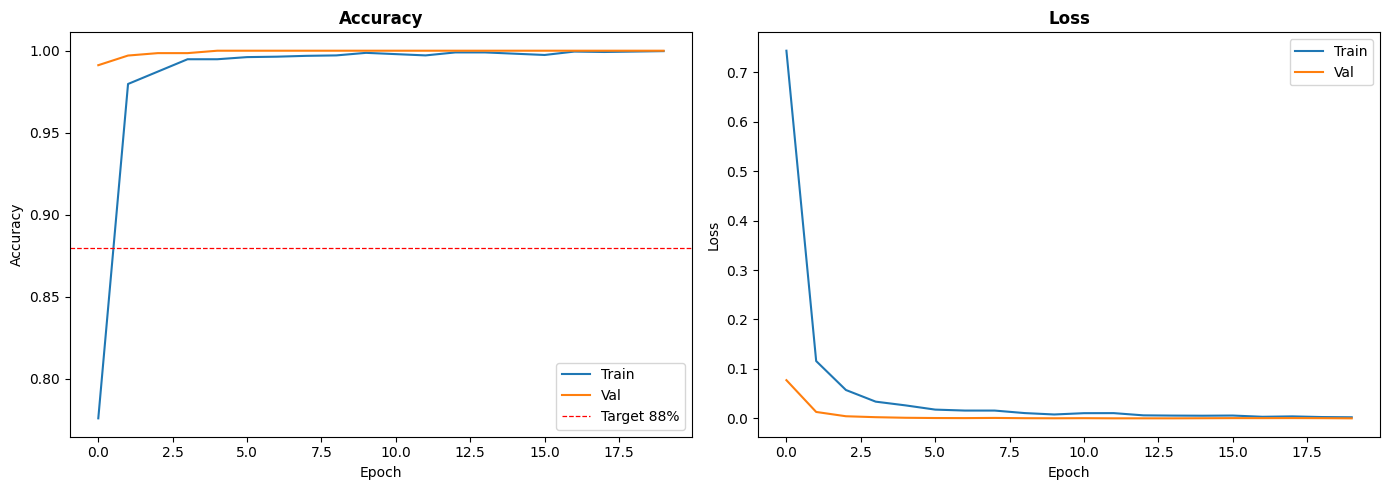

In [19]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].axhline(0.88, ls='--', color='red', lw=0.9, label='Target 88%')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_curves.png', dpi=150)
plt.show()

---
## 9. Model Evaluation

Test Accuracy  : 100.00%
Test Loss      : 0.0005

Classification Report (Keras Model):
              precision    recall  f1-score   support

         Nod       1.00      1.00      1.00       129
  Head_Shake       1.00      1.00      1.00       154
   Tilt_Left       1.00      1.00      1.00       169
  Tilt_Right       1.00      1.00      1.00       162
     Look_Up       1.00      1.00      1.00       163
   Look_Down       1.00      1.00      1.00       177
        Idle       1.00      1.00      1.00       179

    accuracy                           1.00      1133
   macro avg       1.00      1.00      1.00      1133
weighted avg       1.00      1.00      1.00      1133



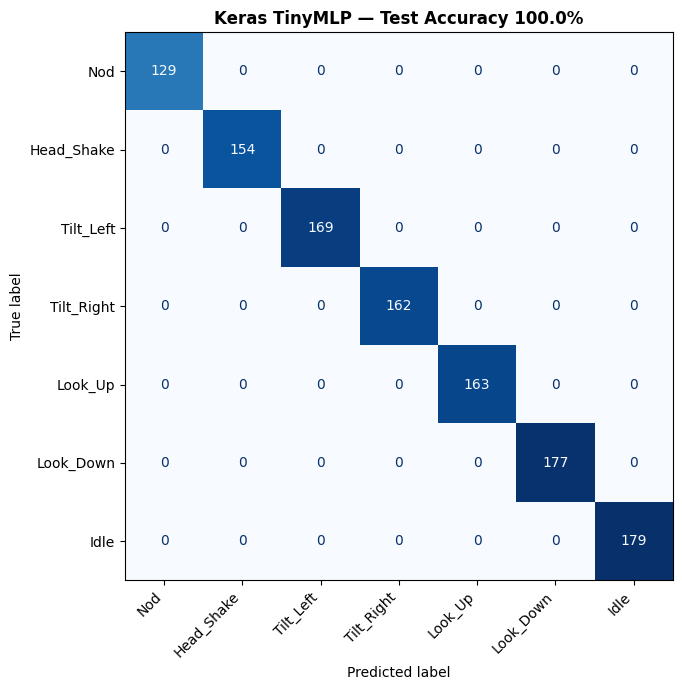

In [20]:
loss, acc = model.evaluate(X_test_s, y_test_oh, verbose=0)
print(f'Test Accuracy  : {acc*100:.2f}%')
print(f'Test Loss      : {loss:.4f}')

y_pred_keras = np.argmax(model.predict(X_test_s, verbose=0), axis=1)

print('\nClassification Report (Keras Model):')
print(classification_report(y_test, y_pred_keras, target_names=target_names))

# Confusion matrix
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_keras),
    display_labels=target_names
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Keras TinyMLP — Test Accuracy {acc*100:.1f}%', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/cm_keras.png', dpi=150)
plt.show()

In [21]:
# Summary comparison
print('=' * 50)
print('     MODEL PERFORMANCE SUMMARY')
print('=' * 50)
print(f'  Decision Tree   : {acc_dt*100:.2f}%')
print(f'  Random Forest   : {acc_rf*100:.2f}%')
print(f'  Keras TinyMLP   : {acc*100:.2f}%')
print('=' * 50)
print(f'  Target           : >= 88.00%')
target_met = acc >= 0.88
print(f'  Target met?      : {"YES ✓" if target_met else "NO ✗ (re-tune needed)"}')

     MODEL PERFORMANCE SUMMARY
  Decision Tree   : 100.00%
  Random Forest   : 100.00%
  Keras TinyMLP   : 100.00%
  Target           : >= 88.00%
  Target met?      : YES ✓


---
## 10. TFLite Export (Edge Impulse Compatible)

We export both a full-precision (float32) and an INT8-quantised TFLite model.  
The quantised model targets the Nicla Vision's 80 MHz Cortex-M7.

In [22]:
# ── Float32 TFLite ────────────────────────────────────────────────────────
converter_f32 = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_f32    = converter_f32.convert()

tflite_f32_path = f'{OUTPUT_DIR}/head_gesture_f32.tflite'
with open(tflite_f32_path, 'wb') as f:
    f.write(tflite_f32)
print(f'Float32 TFLite size : {len(tflite_f32)/1024:.1f} KB → {tflite_f32_path}')


# ── INT8 Quantised TFLite ─────────────────────────────────────────────────
def representative_dataset():
    """Provide calibration data for INT8 quantisation."""
    # Use the training set as calibration data
    n_cal = min(500, len(X_train_s))
    indices = np.random.choice(len(X_train_s), n_cal, replace=False)
    for idx in indices:
        sample = X_train_s[idx:idx+1].astype(np.float32)
        yield [sample]

converter_int8 = tf.lite.TFLiteConverter.from_keras_model(model)
converter_int8.optimizations = [tf.lite.Optimize.DEFAULT]
converter_int8.representative_dataset = representative_dataset
converter_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_int8.inference_input_type  = tf.int8
converter_int8.inference_output_type = tf.int8

tflite_int8 = converter_int8.convert()
tflite_int8_path = f'{OUTPUT_DIR}/head_gesture_int8.tflite'
with open(tflite_int8_path, 'wb') as f:
    f.write(tflite_int8)
print(f'INT8 TFLite size    : {len(tflite_int8)/1024:.1f} KB → {tflite_int8_path}')

INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpap67_0q9\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpap67_0q9\assets


Saved artifact at 'C:\Users\User\AppData\Local\Temp\tmpap67_0q9'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150), dtype=tf.float32, name='features')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  1938259893840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1938260380176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1938259533008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1938259533392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1938261047248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1938259533200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1938259537808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1938259537424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1938259537616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1938259537232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1938259533584: Ten

INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmp0rywcryb\assets


Saved artifact at 'C:\Users\User\AppData\Local\Temp\tmp0rywcryb'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150), dtype=tf.float32, name='features')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  1938259893840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1938260380176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1938259533008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1938259533392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1938261047248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1938259533200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1938259537808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1938259537424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1938259537616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1938259537232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1938259533584: Ten

In [23]:
# ── Validate INT8 TFLite accuracy ─────────────────────────────────────────
interpreter = tf.lite.Interpreter(model_content=tflite_int8)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Get quantisation parameters
in_scale, in_zero_point   = input_details[0]['quantization']
out_scale, out_zero_point = output_details[0]['quantization']

print(f'Input  quantisation : scale={in_scale:.6f}, zero_point={in_zero_point}')
print(f'Output quantisation : scale={out_scale:.6f}, zero_point={out_zero_point}')

tflite_preds = []
for i in range(len(X_test_s)):
    inp_f32  = X_test_s[i:i+1].astype(np.float32)
    inp_int8 = (inp_f32 / in_scale + in_zero_point).astype(np.int8)
    interpreter.set_tensor(input_details[0]['index'], inp_int8)
    interpreter.invoke()
    out_int8 = interpreter.get_tensor(output_details[0]['index'])
    out_f32  = (out_int8.astype(np.float32) - out_zero_point) * out_scale
    tflite_preds.append(np.argmax(out_f32))

tflite_acc = accuracy_score(y_test, tflite_preds)
print(f'\nINT8 TFLite Test Accuracy : {tflite_acc*100:.2f}%')
print(f'Accuracy drop vs Keras    : {(acc - tflite_acc)*100:.2f}%')

Input  quantisation : scale=0.113006, zero_point=-34
Output quantisation : scale=0.003906, zero_point=-128

INT8 TFLite Test Accuracy : 100.00%
Accuracy drop vs Keras    : 0.00%


In [24]:
# ── Generate C hex array for Arduino embedding ─────────────────────────────
hex_path = f'{OUTPUT_DIR}/head_gesture_int8_model.h'
with open(tflite_int8_path, 'rb') as f:
    model_bytes = f.read()

with open(hex_path, 'w') as f:
    f.write('// Auto-generated TFLite model header\n')
    f.write(f'// Model: HeadGesture_TinyMLP  | INT8 | {len(model_bytes)} bytes\n\n')
    f.write('#ifndef HEAD_GESTURE_MODEL_H\n')
    f.write('#define HEAD_GESTURE_MODEL_H\n\n')
    f.write(f'const unsigned int head_gesture_model_len = {len(model_bytes)};\n')
    f.write('const unsigned char head_gesture_model[] = {\n  ')
    for i, byte in enumerate(model_bytes):
        f.write(f'0x{byte:02x}')
        if i < len(model_bytes) - 1:
            f.write(', ')
        if (i + 1) % 16 == 0:
            f.write('\n  ')
    f.write('\n};\n\n')
    f.write('#endif // HEAD_GESTURE_MODEL_H\n')

print(f'Model header saved → {hex_path}')
print(f'Model size: {len(model_bytes):,} bytes ({len(model_bytes)/1024:.1f} KB)')

Model header saved → model_output/head_gesture_int8_model.h
Model size: 40,000 bytes (39.1 KB)


---
## 11. Final Summary

In [25]:
print()
print('╔══════════════════════════════════════════════════════╗')
print('║      HEAD GESTURE RECOGNITION — PIPELINE SUMMARY    ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  Raw samples loaded       : {len(raw):>8,}                ║')
print(f'║  Windows (50 samples,50%) : {len(segments):>8,}                ║')
print(f'║  Feature dimensionality   : {feat_df.shape[1]:>8,}                ║')
print(f'║                           :                          ║')
print(f'║  Decision Tree Accuracy   : {acc_dt*100:>8.2f}%               ║')
print(f'║  Random Forest Accuracy   : {acc_rf*100:>8.2f}%               ║')
print(f'║  Keras TinyMLP Accuracy   : {acc*100:>8.2f}%               ║')
print(f'║  INT8 TFLite Accuracy     : {tflite_acc*100:>8.2f}%               ║')
print(f'║                           :                          ║')
print(f'║  Float32 model size       : {len(tflite_f32)/1024:>7.1f} KB              ║')
print(f'║  INT8 model size          : {len(tflite_int8)/1024:>7.1f} KB              ║')
print('╠══════════════════════════════════════════════════════╣')
print('║  Output artifacts:                                   ║')
print(f'║  → model_output/best_model.h5                        ║')
print(f'║  → model_output/head_gesture_int8.tflite             ║')
print(f'║  → model_output/head_gesture_int8_model.h            ║')
print(f'║  → model_output/scaler.pkl                           ║')
print('╚══════════════════════════════════════════════════════╝')


╔══════════════════════════════════════════════════════╗
║      HEAD GESTURE RECOGNITION — PIPELINE SUMMARY    ║
╠══════════════════════════════════════════════════════╣
║  Raw samples loaded       :  141,751                ║
║  Windows (50 samples,50%) :    5,661                ║
║  Feature dimensionality   :      150                ║
║                           :                          ║
║  Decision Tree Accuracy   :   100.00%               ║
║  Random Forest Accuracy   :   100.00%               ║
║  Keras TinyMLP Accuracy   :   100.00%               ║
║  INT8 TFLite Accuracy     :   100.00%               ║
║                           :                          ║
║  Float32 model size       :   120.1 KB              ║
║  INT8 model size          :    39.1 KB              ║
╠══════════════════════════════════════════════════════╣
║  Output artifacts:                                   ║
║  → model_output/best_model.h5                        ║
║  → model_output/head_gesture_int8.tfli

Model Retraining

In [41]:
# =========================
# IMPORTS
# =========================
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import m2cgen as m2c
import json

# =========================
# CONFIG
# =========================
CLASS_NAMES = {
    1: "Nod",
    2: "Head_Shake",
    3: "Tilt_Left",
    4: "Tilt_Right",
    5: "Look_Up",
    6: "Look_Down",
    7: "Idle"
}

ALL_IMU = [
    'ax1','ay1','az1','gx1','gy1','gz1',
    'ax2','ay2','az2','gx2','gy2','gz2'
]

In [42]:
def extract_features_from_window(window: np.ndarray) -> dict:

    features = {}

    # -------- PER CHANNEL --------
    for i, col in enumerate(ALL_IMU):
        x = window[:, i].astype(np.float64)

        features[f'{col}_mean'] = np.mean(x)
        features[f'{col}_std']  = np.std(x)
        features[f'{col}_min']  = np.min(x)
        features[f'{col}_max']  = np.max(x)
        features[f'{col}_var']  = np.var(x)
        features[f'{col}_rms']  = np.sqrt(np.mean(x**2))
        features[f'{col}_eng']  = np.sum(x**2)
        features[f'{col}_iqr']  = stats.iqr(x)
        features[f'{col}_med']  = np.median(x)

    # -------- CROSS FEATURES --------
    gx1, gx2 = window[:,3], window[:,9]
    gz1, gz2 = window[:,5], window[:,11]
    ay1, ay2 = window[:,1], window[:,7]

    features['cross_gx_mean_diff'] = np.mean(gx1) - np.mean(gx2)
    features['cross_gx_rms_diff']  = np.sqrt(np.mean(gx1**2)) - np.sqrt(np.mean(gx2**2))
    features['cross_gz_mean_diff'] = np.mean(gz1) - np.mean(gz2)
    features['total_gyro_energy']  = np.sum(gx1**2) + np.sum(gz1**2) + np.sum(gx2**2) + np.sum(gz2**2)
    features['cross_ay_mean_diff'] = np.mean(ay1) - np.mean(ay2)

    return features

In [43]:
# BUILD DATASET
# =========================
feature_rows = []
labels_list  = []

for window, cls_idx in segments:
    feat = extract_features_from_window(window)
    feature_rows.append(feat)
    labels_list.append(cls_idx)

feat_df = pd.DataFrame(feature_rows)
y_raw   = np.array(labels_list)

# Fill NaNs
feat_df.fillna(0.0, inplace=True)

print("Feature shape:", feat_df.shape)

Feature shape: (5661, 113)


In [44]:
feature_order = feat_df.columns.tolist()

with open("feature_order.json", "w") as f:
    json.dump(feature_order, f, indent=2)

print("Feature order saved!")


Feature order saved!


In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    feat_df.values,
    y_raw,
    test_size=0.2,
    stratify=y_raw,
    random_state=42
)


In [46]:
dt = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=15,   # good for embedded
    random_state=42
)

dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

In [47]:
y_pred = dt.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {acc*100:.2f}%\n")

print("Classification Report:\n")
target_names = [CLASS_NAMES[i] for i in sorted(CLASS_NAMES.keys())]
print(classification_report(y_test, y_pred, target_names=target_names))


Accuracy: 100.00%

Classification Report:

              precision    recall  f1-score   support

         Nod       1.00      1.00      1.00       129
  Head_Shake       1.00      1.00      1.00       154
   Tilt_Left       1.00      1.00      1.00       169
  Tilt_Right       1.00      1.00      1.00       162
     Look_Up       1.00      1.00      1.00       163
   Look_Down       1.00      1.00      1.00       177
        Idle       1.00      1.00      1.00       179

    accuracy                           1.00      1133
   macro avg       1.00      1.00      1.00      1133
weighted avg       1.00      1.00      1.00      1133



In [48]:
code = m2c.export_to_python(dt)

exec(code)  # creates score()

sample = X_test[0].tolist()

print("\nSanity Check:")
print("Sklearn :", dt.predict([sample])[0])
print("m2cgen  :", score(sample))


Sanity Check:
Sklearn : 4
m2cgen  : [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0]


In [49]:
with open("model_score.py", "w") as f:
    f.write(code)

print("\n✅ m2cgen model saved as model_score.py")


✅ m2cgen model saved as model_score.py


In [50]:
print(code)

def score(input):
    if input[78] <= 2.9801491498947144:
        if input[111] <= 6447.829833984375:
            if input[8] <= 0.5377808511257172:
                if input[3] <= -0.1123657338321209:
                    var0 = [0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0]
                else:
                    if input[42] <= 3293.8863525390625:
                        var0 = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0]
                    else:
                        var0 = [0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]
            else:
                var0 = [0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0]
        else:
            if input[96] <= 10047.057373046875:
                if input[3] <= -0.1484375186264515:
                    var0 = [0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0]
                else:
                    if input[51] <= 4963.455078125:
                        var0 = [0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0]
                    else:
                        var0 = [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
          

In [51]:
print(len(feat_df.columns))
for i, col in enumerate(feat_df.columns):
    print(i, col)

113
0 ax1_mean
1 ax1_std
2 ax1_min
3 ax1_max
4 ax1_var
5 ax1_rms
6 ax1_eng
7 ax1_iqr
8 ax1_med
9 ay1_mean
10 ay1_std
11 ay1_min
12 ay1_max
13 ay1_var
14 ay1_rms
15 ay1_eng
16 ay1_iqr
17 ay1_med
18 az1_mean
19 az1_std
20 az1_min
21 az1_max
22 az1_var
23 az1_rms
24 az1_eng
25 az1_iqr
26 az1_med
27 gx1_mean
28 gx1_std
29 gx1_min
30 gx1_max
31 gx1_var
32 gx1_rms
33 gx1_eng
34 gx1_iqr
35 gx1_med
36 gy1_mean
37 gy1_std
38 gy1_min
39 gy1_max
40 gy1_var
41 gy1_rms
42 gy1_eng
43 gy1_iqr
44 gy1_med
45 gz1_mean
46 gz1_std
47 gz1_min
48 gz1_max
49 gz1_var
50 gz1_rms
51 gz1_eng
52 gz1_iqr
53 gz1_med
54 ax2_mean
55 ax2_std
56 ax2_min
57 ax2_max
58 ax2_var
59 ax2_rms
60 ax2_eng
61 ax2_iqr
62 ax2_med
63 ay2_mean
64 ay2_std
65 ay2_min
66 ay2_max
67 ay2_var
68 ay2_rms
69 ay2_eng
70 ay2_iqr
71 ay2_med
72 az2_mean
73 az2_std
74 az2_min
75 az2_max
76 az2_var
77 az2_rms
78 az2_eng
79 az2_iqr
80 az2_med
81 gx2_mean
82 gx2_std
83 gx2_min
84 gx2_max
85 gx2_var
86 gx2_rms
87 gx2_eng
88 gx2_iqr
89 gx2_med
90 gy2

In [52]:
code = m2c.export_to_python(dt)
exec(code)

sample = X_test[0].tolist()

print(len(sample))        # should be 113
print(dt.predict([sample]))
print(score(sample))      # must match

113
[4]
[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0]


In [53]:
code = m2c.export_to_python(dt)
exec(code)

sample = X_test[0].tolist()

print("Len:", len(sample))          # must be 113
print("Sklearn:", dt.predict([sample])[0])
print("m2cgen :", score(sample))

Len: 113
Sklearn: 4
m2cgen : [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0]
